In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score




In [2]:

PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

ALL_FEATURES = ["pv","temperature","glob_radiation_wm2", "niederschlag", "sun_hours",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos", "month_sin", "month_cos"
]

PAST_FEATURES = ["pv", "temperature", "glob_radiation_wm2", "niederschlag", "sun_hours"]

ALL_ALL_FEATURES = PAST_FEATURES + ALL_FEATURES
# Time-series lags (hours)
LAGS = [1, 2, 3, 4, 5, 6, 12, 24]

In [166]:
weather_df = pd.read_csv(
        WEATHER_CSV_PATH,
        sep=",",
        parse_dates=["time"],
        index_col="time"
    )

In [167]:
weather_df.columns

Index(['station', 'windspeed_ms', 'pressure_hPa', 'rel_hum', 'niederschlag',
       'sun_hours', 'temperature', 'glob_radiation_wm2'],
      dtype='object')

In [7]:
#  PREPROCESSING PIPELINE


def load_and_merge():
    # --- Load PV data (5-min → hourly) ---
    pv_df = pd.read_csv(
        PV_CSV_PATH, sep=",",
        parse_dates=["timestamp"],
        index_col="timestamp"
    )
    pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
    pv_hourly = pv_df.resample("1h").mean()

    # --- Load weather data ---
    weather_df = pd.read_csv(
        WEATHER_CSV_PATH,
        sep=",",
        parse_dates=["time"],
        index_col="time"
    )
    if weather_df.index.tz is not None:
        weather_df.index = weather_df.index.tz_convert(None)
    weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

    # date range fix
    weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

    # --- Merge PV + weather ---
    df = pv_hourly.join(weather_df, how="inner")

    #df = df.iloc[3500:] # to get rid of earlier dates which have almost no pv output, since it makes harder to predict summer months

    # --- Time features ---
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["weekofyear"] = df.index.isocalendar().week
    df["month"] = df.index.month

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["woy_sin"]  = np.sin(2*np.pi*df["weekofyear"]/52)
    df["woy_cos"]  = np.cos(2*np.pi*df["weekofyear"]/52)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

    df = df[ALL_FEATURES]
    df = df.replace(["None","nan","NaN",""], pd.NA).ffill().bfill()

    return df


def scale_and_split(df):


    train_start = "2024-07-01"
    train_end   = "2025-06-30"

    val_start   = "2025-07-01"
    val_end     = "2025-08-31"

    # test split 2
    test_start  = "2025-09-01"
    test_end    = "2025-10-30"

    # test split 1
    #test_start  = "2025-04-01"
    #test_end    = "2025-05-31"

    df_train = df.loc[train_start:train_end]
    df_val   = df.loc[val_start:val_end]
    df_test  = df.loc[test_start:test_end]

    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()

    scaler_X.fit(df_train[ALL_FEATURES])
    scaler_Y.fit(df_train[[TARGET_COL]])

    allowed_index = df_train.index.union(df_val.index).union(df_test.index)
    df_scaled = df.loc[allowed_index].copy()

    df_scaled.loc[df_train.index, ALL_FEATURES] = scaler_X.transform(df_train[ALL_FEATURES])
    df_scaled.loc[df_val.index,   ALL_FEATURES] = scaler_X.transform(df_val[ALL_FEATURES])
    df_scaled.loc[df_test.index,  ALL_FEATURES] = scaler_X.transform(df_test[ALL_FEATURES])

    df_scaled.loc[df_train.index, TARGET_COL] = scaler_Y.transform(df_train[[TARGET_COL]])
    df_scaled.loc[df_val.index,   TARGET_COL] = scaler_Y.transform(df_val[[TARGET_COL]])
    df_scaled.loc[df_test.index,  TARGET_COL] = scaler_Y.transform(df_test[[TARGET_COL]])

    return df_scaled, scaler_X, scaler_Y, df_train.index, df_val.index, df_test.index



def create_lag_features(df_scaled, train_idx, val_idx, test_idx):

    df_ml = df_scaled.copy()

    for lag in LAGS:
        df_ml[f"pv_lag{lag}"]  = df_ml["pv"].shift(lag)
        df_ml[f"temp_lag{lag}"] = df_ml["temperature"].shift(lag)
        df_ml[f"rad_lag{lag}"]  = df_ml["glob_radiation_wm2"].shift(lag)
        df_ml[f"nied_lag{lag}"]  = df_ml["niederschlag"].shift(lag)
        df_ml[f"sun_lag{lag}"]  = df_ml["sun_hours"].shift(lag)

    df_ml = df_ml.dropna()

    lag_features = [c for c in df_ml.columns if ("lag" in c)]

    time_features = [
        "hour_sin","hour_cos",
        "dow_sin","dow_cos",
        "woy_sin","woy_cos",
        "month_sin", "month_cos"
    ]

    FEATURE_COLS = lag_features + time_features

    # Split
    df_train_ml = df_ml.loc[df_ml.index.intersection(train_idx)]
    df_val_ml   = df_ml.loc[df_ml.index.intersection(val_idx)]
    df_test_ml  = df_ml.loc[df_ml.index.intersection(test_idx)]

    X_train = df_train_ml[FEATURE_COLS]
    y_train = df_train_ml[TARGET_COL]

    X_val = df_val_ml[FEATURE_COLS]
    y_val = df_val_ml[TARGET_COL]

    X_test = df_test_ml[FEATURE_COLS]
    y_test = df_test_ml[TARGET_COL]

    return X_train, y_train, X_val, y_val, X_test, y_test, FEATURE_COLS



# MAIN PREPROCESS FUNCTION

def preprocess_all():
    df = load_and_merge()

    df_scaled, scaler_X, scaler_Y, train_idx, val_idx, test_idx = scale_and_split(df)

    X_train, y_train, X_val, y_val, X_test, y_test, FEATURES = create_lag_features(
        df_scaled, train_idx, val_idx, test_idx
    )

    return df, df_scaled, X_train, y_train, X_val, y_val, X_test, y_test, scaler_Y, FEATURES



# Run preprocessing
(
    df, df_scaled,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    scaler_y, FEATURES
) = preprocess_all()

print("Shapes:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


C:\Users\dogan\AppData\Local\Temp\ipykernel_26672\1251262032.py:6: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pv_df = pd.read_csv(


Shapes:
Train: (8736, 49)
Val:   (1488, 49)
Test:  (1200, 49)


C:\Users\dogan\AppData\Local\Temp\ipykernel_26672\1251262032.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.63305083 -0.63305083 -0.63305083 ... -0.63305083 -0.63305083
 -0.63305083]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[df_train.index, ALL_FEATURES] = scaler_X.transform(df_train[ALL_FEATURES])


In [169]:
X_test.columns

Index(['niederschlag', 'pv_lag1', 'temp_lag1', 'rad_lag1', 'nied_lag1',
       'sun_lag1', 'pv_lag2', 'temp_lag2', 'rad_lag2', 'nied_lag2', 'sun_lag2',
       'pv_lag3', 'temp_lag3', 'rad_lag3', 'nied_lag3', 'sun_lag3', 'pv_lag4',
       'temp_lag4', 'rad_lag4', 'nied_lag4', 'sun_lag4', 'pv_lag5',
       'temp_lag5', 'rad_lag5', 'nied_lag5', 'sun_lag5', 'pv_lag6',
       'temp_lag6', 'rad_lag6', 'nied_lag6', 'sun_lag6', 'pv_lag12',
       'temp_lag12', 'rad_lag12', 'nied_lag12', 'sun_lag12', 'pv_lag24',
       'temp_lag24', 'rad_lag24', 'nied_lag24', 'sun_lag24', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'woy_sin', 'woy_cos', 'month_sin',
       'month_cos'],
      dtype='object')

In [8]:
import optuna
from sklearn.metrics import mean_squared_error

# testing different hyperparams

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    pred_val = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    return rmse
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler = sampler)
study.optimize(objective, n_trials=200)

print("Best parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2025-11-19 18:17:30,924] A new study created in memory with name: no-name-95741057-8ab7-48c0-b6f0-5a42ae07cd38
[I 2025-11-19 18:17:32,629] Trial 0 finished with value: 0.2323041496825332 and parameters: {'n_estimators': 500, 'learning_rate': 0.19063571821788408, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.2323041496825332.
[I 2025-11-19 18:17:35,515] Trial 1 finished with value: 0.23058971002283418 and parameters: {'n_estimators': 767, 'learning_rate': 0.013911053916202464, 'max_depth': 10, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 1.0495128632644757}. Best is trial 1 with value: 0.23058971002283418.
[I 2025-11-19 18:17:36,864] Trial 2 finished with value: 0.24253

Best parameters: {'n_estimators': 523, 'learning_rate': 0.05332636321695519, 'max_depth': 4, 'subsample': 0.5040636246785095, 'colsample_bytree': 0.8856436148313241, 'min_child_weight': 1, 'gamma': 0.14476494219252783, 'reg_alpha': 0.05231643473987582, 'reg_lambda': 1.6104086632522034}
Best RMSE: 0.21474504950266693



Final Model RMSEs (Using Tuned Parameters):
Val RMSE: 0.21474504950266693
Test RMSE: 0.28263328174906455
Val R2: 0.966276237087559
Test R2: 0.8846392263557861


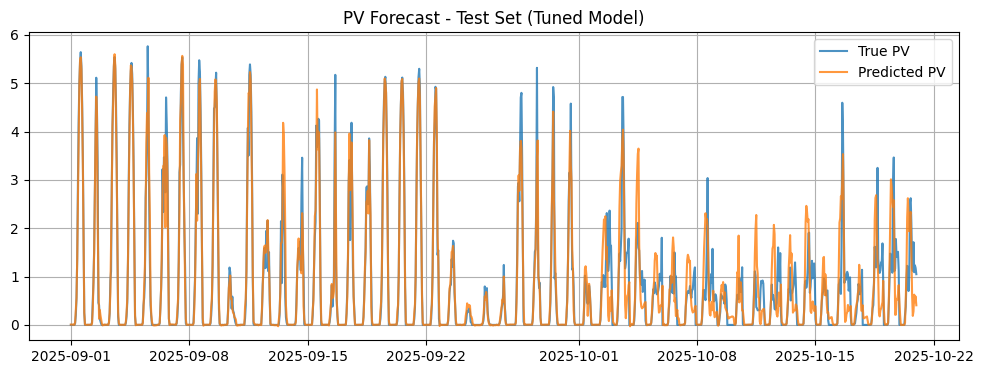

Next-step PV prediction: 0.40592167607310325


In [9]:
best_params = study.best_params
best_params["objective"] = "reg:squarederror"
best_params["random_state"] = 42

model = xgb.XGBRegressor(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

###
pred_val = model.predict(X_val)
pred_test = model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\nFinal Model RMSEs (Using Tuned Parameters):")
print("Val RMSE:", rmse(y_val, pred_val))
print("Test RMSE:", rmse(y_test, pred_test))

print("Val R2:", r2_score(y_val, pred_val))
print("Test R2:", r2_score(y_test, pred_test))


# INVERSE SCALE & PLOT

test_index = y_test.index  # for date on axis

pred_test_inv = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_test_inv    = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(test_index,y_test_inv, label="True PV", alpha=0.8)
plt.plot(test_index, pred_test_inv, label="Predicted PV", alpha=0.8)
plt.legend()
plt.grid(True)
plt.title("PV Forecast - Test Set (Tuned Model)")
plt.show()

# Next-step prediction
next_pred_scaled = model.predict(X_test.iloc[-1:])[0]
next_pred = scaler_y.inverse_transform([[next_pred_scaled]])[0][0]
print("Next-step PV prediction:", next_pred)

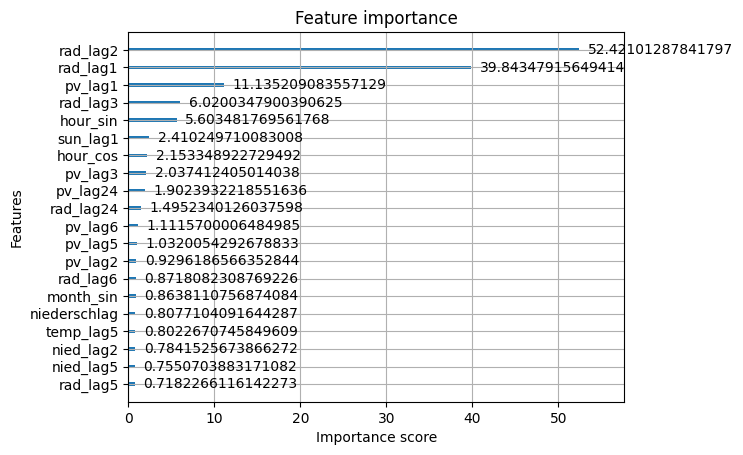

In [10]:
xgb.plot_importance(model, importance_type="gain", max_num_features=20)
plt.show()

In [173]:
X_test

,niederschlag,pv_lag1,temp_lag1,rad_lag1,nied_lag1,sun_lag1,pv_lag2,temp_lag2,rad_lag2,nied_lag2,sun_lag2,pv_lag3,temp_lag3,rad_lag3,nied_lag3,sun_lag3,pv_lag4,temp_lag4,rad_lag4,nied_lag4,sun_lag4,pv_lag5,temp_lag5,rad_lag5,nied_lag5,sun_lag5,pv_lag6,temp_lag6,rad_lag6,nied_lag6,sun_lag6,pv_lag12,temp_lag12,rad_lag12,nied_lag12,sun_lag12,pv_lag24,temp_lag24,rad_lag24,nied_lag24,sun_lag24,hour_sin,hour_cos,dow_sin,dow_cos,woy_sin,woy_cos,month_sin,month_cos
2025-04-01 00:00:00,-0.140259,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,-0.436072,-0.787432,-0.611906,-0.140259,-0.602764,-0.431920,-0.787432,-0.611906,-0.140259,-0.602764,-0.333365,-0.702811,-0.597914,-0.140259,-0.602764,0.075527,-0.639345,1.402963,1.120645,0.415525,-0.436072,-0.660501,-0.611906,-0.140259,-0.602764,2.275496e-17,1.414214,1.102018,0.867506,5.103266,-0.238836,4.413219,-0.963570
2025-04-01 01:00:00,-0.140259,-0.436072,-0.713389,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,-0.436072,-0.787432,-0.611906,-0.140259,-0.602764,-0.431920,-0.787432,-0.611906,-0.140259,-0.602764,0.564978,-0.311439,1.435611,-0.000159,1.179241,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,3.660254e-01,1.366025,1.102018,0.867506,5.103266,-0.238836,4.413219,-0.963570
2025-04-01 02:00:00,-0.140259,-0.436072,-0.723966,-0.611906,-0.140259,-0.602764,-0.436072,-0.713389,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,-0.436072,-0.787432,-0.611906,-0.140259,-0.602764,1.356738,-0.501836,0.278927,0.280042,-0.093620,-0.436072,-0.776854,-0.611906,-0.140259,-0.602764,7.071068e-01,1.224745,1.102018,0.867506,5.103266,-0.238836,4.413219,-0.963570
2025-04-01 03:00:00,-0.140259,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,-0.436072,-0.723966,-0.611906,-0.140259,-0.602764,-0.436072,-0.713389,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,0.389462,-0.343172,1.109128,-0.140259,1.433813,-0.436072,-0.787432,-0.611906,-0.140259,-0.602764,1.000000e+00,1.000000,1.102018,0.867506,5.103266,-0.238836,4.413219,-0.963570
2025-04-01 04:00:00,-0.140259,-0.436072,-0.755699,-0.611906,-0.140259,-0.602764,-0.436072,-0.745122,-0.611906,-0.140259,-0.602764,-0.436072,-0.723966,-0.611906,-0.140259,-0.602764,-0.436072,-0.713389,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,-0.436072,-0.734544,-0.611906,-0.140259,-0.602764,0.185155,-0.565302,-0.010244,-0.140259,0.160952,-0.436072,-0.861475,-0.611906,-0.140259,-0.602764,1.224745e+00,0.707107,1.102018,0.867506,5.103266,-0.238836,4.413219,-0.963570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-31 19:00:00,-0.140259,0.385586,1.180007,-0.434672,-0.140259,-0.348192,0.920439,1.465603,0.451497,-0.140259,1.942958,1.246556,1.560801,1.174424,-0.140259,1.942958,1.440620,1.603112,1.906680,-0.140259,1.942958,1.538898,1.603112,2.606287,-0.140259,1.942958,1.495434,1.476180,3.086684,-0.140259,1.942958,-0.270522,0.809790,1.650157,-0.140259,1.942958,-0.121583,0.407840,-0.551273,-0.140259,-0.093620,-1.366025e+00,0.366025,-1.387725,-0.326506,3.440366,-1.317481,3.326643,-1.494914
2025-05-31 20:00:00,-0.140259,-0.369077,0.979032,-0.551273,-0.140259,-0.602764,0.385586,1.180007,-0.434672,-0.140259,-0.348192,0.920439,1.465603,0.451497,-0.140259,1.942958,1.246556,1.560801,1.174424,-0.140259,1.942958,1.440620,1.603112,1.906680,-0.140259,1.942958,1.538898,1.603112,2.606287,-0.140259,1.942958,-0.039362,1.04249